# Task-1

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
#load a dataset
products=pd.read_csv('products.csv')
customers=pd.read_csv('customers.csv')
sales=pd.read_csv('sales.csv')

In [67]:
products

,product_id,product_name,category,unit_price
0,P001,Laptop,Electronics,800
1,P002,Mouse,Electronics,25
2,P003,Keyboard,Electronics,45
3,P004,Monitor,Electronics,250
4,P005,Webcam,Electronics,60
5,P006,Headphones,Electronics,120
6,P007,USB Hub,Electronics,35
7,P008,Desk Lamp,Office,40
8,P009,Chair,Office,180
9,P010,Standing Desk,Office,400


In [68]:
sales

,order_id,date,customer_id,product_id,quantity
0,O00001,31-10-2024,C999,P019,2
1,O00002,14-03-2024,C999,P014,1
2,O00003,21-10-2024,C999,P004,1
3,O00004,03-01-2024,C999,P003,3
4,O00005,18-10-2024,C999,P018,4
...,...,...,...,...,...
995,O00996,30-01-2024,C039,P016,3
996,O00997,01-11-2024,C047,P004,3
997,O00998,03-10-2024,C044,P007,1
998,O00999,16-01-2024,C038,P004,4


In [69]:
customers

,customer_id,customer_name,region,signup_year
0,C001,Customer_1,North,2024
1,C002,Customer_2,West,2021
2,C003,Customer_3,East,2022
3,C004,Customer_4,South,2022
4,C005,Customer_5,South,2022
5,C006,Customer_6,West,2021
6,C007,Customer_7,North,2023
7,C008,Customer_8,East,2021
8,C009,Customer_9,North,2023
9,C010,Customer_10,North,2023


In [70]:
#merge a 3 dataset
full = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

In [71]:
full = full.merge(
    products,
    on="product_id",
    how="left"
)

In [72]:
#add a revenue column in master table
full["revenue"] = full["quantity"] * full["unit_price"]

In [73]:
#show a whole table
print(full.head())

  order_id        date customer_id product_id  quantity customer_name region  \
0   O00001  31-10-2024        C999       P019         2           NaN    NaN   
1   O00002  14-03-2024        C999       P014         1           NaN    NaN   
2   O00003  21-10-2024        C999       P004         1           NaN    NaN   
3   O00004  03-01-2024        C999       P003         3           NaN    NaN   
4   O00005  18-10-2024        C999       P018         4           NaN    NaN   

   signup_year  product_name     category  unit_price  revenue  
0          NaN    Microphone  Electronics         110      220  
1          NaN  Water Bottle  Accessories          20       20  
2          NaN       Monitor  Electronics         250      250  
3          NaN      Keyboard  Electronics          45      135  
4          NaN       Speaker  Electronics          90      360  


In [74]:
#Find mismatches : unknown customers
unknown_customers = full["region"].isna().sum()

print("Unknown customers:", unknown_customers)

Unknown customers: 5


In [75]:
#show all the rows which is nan
print(full[full["region"].isna()])

  order_id        date customer_id product_id  quantity customer_name region  \
0   O00001  31-10-2024        C999       P019         2           NaN    NaN   
1   O00002  14-03-2024        C999       P014         1           NaN    NaN   
2   O00003  21-10-2024        C999       P004         1           NaN    NaN   
3   O00004  03-01-2024        C999       P003         3           NaN    NaN   
4   O00005  18-10-2024        C999       P018         4           NaN    NaN   

   signup_year  product_name     category  unit_price  revenue  
0          NaN    Microphone  Electronics         110      220  
1          NaN  Water Bottle  Accessories          20       20  
2          NaN       Monitor  Electronics         250      250  
3          NaN      Keyboard  Electronics          45      135  
4          NaN       Speaker  Electronics          90      360  


In [76]:
#Find customers who never ordered
customer_check = customers.merge(
    sales[["customer_id"]].drop_duplicates(),
    on="customer_id",
    how="left",
    indicator=True
)

never_ordered = customer_check[
    customer_check["_merge"] == "left_only"
]

print("Customers who never ordered:", len(never_ordered))
print(never_ordered)

Customers who never ordered: 2
   customer_id customer_name region  signup_year     _merge
50        C051   Customer_51  North         2024  left_only
51        C052   Customer_52  South         2024  left_only


In [77]:
#comapre a join(inner,left,outer)
inner = sales.merge(
    customers,
    on="customer_id",
    how="inner"
)

left = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

outer = sales.merge(
    customers,
    on="customer_id",
    how="outer"
)

In [78]:
print("Inner rows:", len(inner))
print("Left rows:", len(left))
print("Outer rows:", len(outer))

Inner rows: 995
Left rows: 1000
Outer rows: 1002


In [79]:
#I used a left join when merging the customer table because every sale should remain in the revenue report, even if the customer information is missing. 
#An inner join could silently remove sales that reference unknown customers, which would make the revenue report incomplete.

In [80]:
#1. What is the danger of using an INNER JOIN without checking?
#An INNER JOIN removes unmatched rows. Sales with unknown customers would disappear, causing the analysis to undercount sales or revenue.

#2. How can failed customer lookups be found?
#After a LEFT JOIN, check rows where region is NaN.

#3. When is an OUTER JOIN useful?
#An OUTER JOIN is useful when we want to see both matched and unmatched records from both tables.

#4. Which join type was used for the customer merge and why?
#A LEFT JOIN was used because every sale should remain in the master table, even when customer information is missing. 

# Task-2

In [81]:
#Total revenue for each region
full.groupby("region")["revenue"].sum()

region
East     121636
North     83444
South     81814
West     117271
Name: revenue, dtype: int64

In [82]:
region_revenue = (
    full.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(region_revenue)

region
East     121636
West     117271
North     83444
South     81814
Name: revenue, dtype: int64


In [83]:
#Total revenue per product category
category_revenue = (
    full.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Electronics    285690
Office         104000
Accessories     12081
Stationery       3379
Name: revenue, dtype: int64


In [84]:
#Use agg() for multiple calculations: total revenue, average order revenue, and number of orders
category_summary = full.groupby("category").agg(
    total_revenue=("revenue", "sum"),
    average_order_revenue=("revenue", "mean"),
    number_of_orders=("order_id", "count")
)

print(category_summary)


             total_revenue  average_order_revenue  number_of_orders
category                                                           
Accessories          12081              92.930769               130
Electronics         285690             466.813725               612
Office              104000             641.975309               162
Stationery            3379              35.197917                96


In [85]:
#First we need to make sure the date is a datetime.
full["date"] = pd.to_datetime(full["date"], dayfirst=True)

In [86]:
#month column
full["month"] = full["date"].dt.to_period("M")

In [87]:
#Group by two columns(region and month)
region_month = (
    full.groupby(["region", "month"])["revenue"]
    .sum()
)

print(region_month)

region  month  
East    2024-01    11506
        2024-02    11110
        2024-03    13911
        2024-04    10275
        2024-05     5976
        2024-06     6378
        2024-07     9568
        2024-08    12035
        2024-09    12640
        2024-10     8635
        2024-11     5029
        2024-12    14573
North   2024-01     2975
        2024-02    12119
        2024-03     7269
        2024-04     8534
        2024-05    11601
        2024-06     6915
        2024-07     5573
        2024-08     3604
        2024-09     4852
        2024-10     6562
        2024-11     5831
        2024-12     7609
South   2024-01     6114
        2024-02    12525
        2024-03    10415
        2024-04     3930
        2024-05     6320
        2024-06     3685
        2024-07     5078
        2024-08     6931
        2024-09     7848
        2024-10     6331
        2024-11     6404
        2024-12     6233
West    2024-01    11831
        2024-02    12241
        2024-03     6993
        2

In [88]:
#i choose a "West" and now calculate a single best month and its worst month

In [89]:
west_data = region_month.loc["West"]

print(west_data)

month
2024-01    11831
2024-02    12241
2024-03     6993
2024-04     5963
2024-05     3394
2024-06    14742
2024-07    14303
2024-08     8677
2024-09     4520
2024-10     8262
2024-11    16039
2024-12    10306
Freq: M, Name: revenue, dtype: int64


In [90]:
#find a best month
best_month = west_data.idxmax()
best_revenue = west_data.max()

print("Best month:", best_month)
print("Best revenue:", best_revenue)

Best month: 2024-11
Best revenue: 16039


In [91]:
#find a worst month
worst_month = west_data.idxmin()
worst_revenue = west_data.min()

print("Worst month:", worst_month)
print("Worst revenue:", worst_revenue)

Worst month: 2024-05
Worst revenue: 3394


# Task-3

In [92]:
region_category_pivot = full.pivot_table(
    values="revenue",
    index="region",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

print(region_category_pivot)

category  Accessories  Electronics  Office  Stationery
region                                                
East             3379        86260   31020         977
North            2231        56815   23420         978
South            3341        55530   22440         503
West             3110        86120   27120         921


In [93]:
#Build a second pivot with region as rows and month as columns.
region_month_pivot = full.pivot_table(
    values="revenue",
    index="region",
    columns="month",
    aggfunc="sum",
    fill_value=0
)

print(region_month_pivot)

month   2024-01  2024-02  2024-03  2024-04  2024-05  2024-06  2024-07  \
region                                                                  
East      11506    11110    13911    10275     5976     6378     9568   
North      2975    12119     7269     8534    11601     6915     5573   
South      6114    12525    10415     3930     6320     3685     5078   
West      11831    12241     6993     5963     3394    14742    14303   

month   2024-08  2024-09  2024-10  2024-11  2024-12  
region                                               
East      12035    12640     8635     5029    14573  
North      3604     4852     6562     5831     7609  
South      6931     7848     6331     6404     6233  
West       8677     4520     8262    16039    10306  


In [94]:
#crosstab:A crosstab is basically a table that counts occurrences.
order_crosstab = pd.crosstab(
    full["region"],
    full["category"]
)

print(order_crosstab)

category  Accessories  Electronics  Office  Stationery
region                                                
East               33          156      45          26
North              26          143      38          22
South              32          114      36          19
West               38          195      43          29


In [95]:
#Find the highest region-month combination
region_month_revenue = (
    full.groupby(["region", "month"])["revenue"]
    .sum()
)

In [96]:
highest_region_month = region_month_revenue.idxmax()
highest_revenue = region_month_revenue.max()

print("Highest region-month:", highest_region_month)
print("Highest revenue:", highest_revenue)

Highest region-month: ('West', Period('2024-11', 'M'))
Highest revenue: 16039


In [97]:
region_category_total = full.pivot_table(
    values="revenue",
    index="region",
    columns="category",
    aggfunc="sum",
    fill_value=0,
    margins=True
)

print(region_category_total)

category  Accessories  Electronics  Office  Stationery     All
region                                                        
East             3379        86260   31020         977  121636
North            2231        56815   23420         978   83444
South            3341        55530   22440         503   81814
West             3110        86120   27120         921  117271
All             12061       284725  104000        3379  404165


# Task-4

In [98]:
# 1. Convert date column to datetime
full["date"] = pd.to_datetime(full["date"], dayfirst=True)

In [99]:
# 2. Extract month
full["month"] = full["date"].dt.month

In [100]:
# 3. Extract day name
full["day_name"] = full["date"].dt.day_name()

In [101]:
# 4. Extract quarter
full["quarter"] = full["date"].dt.quarter


In [102]:
# 5. Revenue by day of week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

full["day_name"] = pd.Categorical(
    full["day_name"],
    categories=day_order,
    ordered=True
)

day_revenue = (
    full.groupby("day_name", observed=True)["revenue"]
    .sum()
)

print("Revenue by day of week:")
print(day_revenue)

Revenue by day of week:
day_name
Monday       51266
Tuesday      61293
Wednesday    43207
Thursday     67003
Friday       56667
Saturday     50325
Sunday       75389
Name: revenue, dtype: int64


In [103]:
# 6. Highest revenue day
best_day = day_revenue.idxmax()
best_day_revenue = day_revenue.max()

print("\nHighest revenue day:", best_day)
print("Revenue:", best_day_revenue)



Highest revenue day: Sunday
Revenue: 75389


In [104]:
# 7. Monthly revenue
monthly = (
    full.set_index("date")
    .resample("ME")["revenue"]
    .sum()
)

print("\nMonthly revenue:")
print(monthly)



Monthly revenue:
date
2024-01-31    32561
2024-02-29    47995
2024-03-31    38608
2024-04-30    28702
2024-05-31    27291
2024-06-30    31720
2024-07-31    34522
2024-08-31    31247
2024-09-30    29860
2024-10-31    30620
2024-11-30    33303
2024-12-31    38721
Freq: ME, Name: revenue, dtype: int64


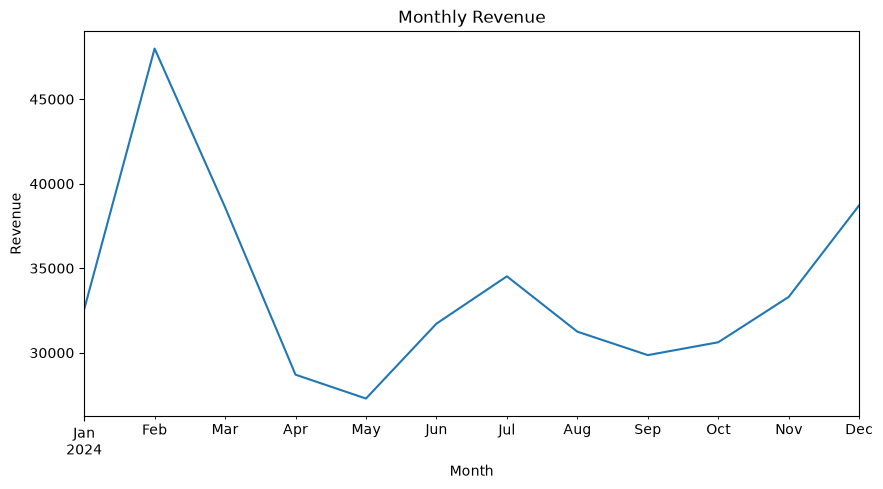

In [105]:
# 8. Monthly revenue plot
monthly.plot(
    kind="line",
    figsize=(10, 5),
    title="Monthly Revenue"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [63]:
# 9. Weekly revenue
weekly = (
    full.set_index("date")
    .resample("W")["revenue"]
    .sum()
)

print("\nWeekly revenue:")
print(weekly)


Weekly revenue:
date
2024-01-07    10707
2024-01-14    13783
2024-01-21     4246
2024-01-28     2010
2024-02-04    16042
2024-02-11     7075
2024-02-18     8341
2024-02-25    11364
2024-03-03     9165
2024-03-10    10069
2024-03-17    12075
2024-03-24     2690
2024-03-31    11597
2024-04-07     3715
2024-04-14     7409
2024-04-21     8384
2024-04-28     6168
2024-05-05    12247
2024-05-12     1771
2024-05-19    12203
2024-05-26      801
2024-06-02     6715
2024-06-09     8867
2024-06-16     5530
2024-06-23     5684
2024-06-30     8219
2024-07-07     7220
2024-07-14    10638
2024-07-21     9017
2024-07-28     6306
2024-08-04     5870
2024-08-11     6679
2024-08-18     4196
2024-08-25     5609
2024-09-01    12520
2024-09-08     5980
2024-09-15     7768
2024-09-22     4559
2024-09-29     7882
2024-10-06     5163
2024-10-13     9534
2024-10-20    10115
2024-10-27     3341
2024-11-03    14957
2024-11-10     6453
2024-11-17     2840
2024-11-24     5705
2024-12-01     9370
2024-12-08    1085

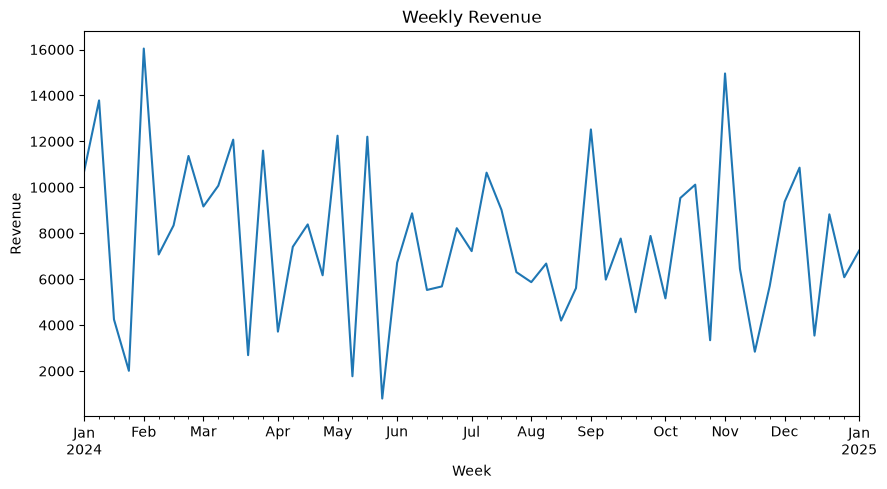

In [106]:
# 10. Weekly revenue plot
weekly.plot(
    kind="line",
    figsize=(10, 5),
    title="Weekly Revenue"
)

plt.xlabel("Week")
plt.ylabel("Revenue")
plt.show()

# Task-5

In [125]:
#product name convert into upper case
products["product_name"].str.upper()

0            LAPTOP
1             MOUSE
2          KEYBOARD
3           MONITOR
4            WEBCAM
5        HEADPHONES
6           USB HUB
7         DESK LAMP
8             CHAIR
9     STANDING DESK
10         NOTEBOOK
11          PEN SET
12         BACKPACK
13     WATER BOTTLE
14      PHONE STAND
15        CABLE SET
16       POWER BANK
17          SPEAKER
18       MICROPHONE
19           TABLET
Name: product_name, dtype: str

In [ ]:
#in the name contains "a" then print it
products[products["product_name"].str.contains("a", case=False)]

,product_id,product_name,category,unit_price
0,P001,Laptop,Electronics,800
2,P003,Keyboard,Electronics,45
4,P005,Webcam,Electronics,60
5,P006,Headphones,Electronics,120
7,P008,Desk Lamp,Office,40
8,P009,Chair,Office,180
9,P010,Standing Desk,Office,400
12,P013,Backpack,Accessories,55
13,P014,Water Bottle,Accessories,20
14,P015,Phone Stand,Accessories,18


In [ ]:
#contain "phone" than print
products[
    products["product_name"].str.contains(
        "phone",
        case=False,
        na=False
    )
]

,product_id,product_name,category,unit_price
5,P006,Headphones,Electronics,120
14,P015,Phone Stand,Accessories,18
18,P019,Microphone,Electronics,110


In [126]:
#category name convert into upper
products["category_upper"] = products["category"].str.upper()
products["category_upper"]

0     ELECTRONICS
1     ELECTRONICS
2     ELECTRONICS
3     ELECTRONICS
4     ELECTRONICS
5     ELECTRONICS
6     ELECTRONICS
7          OFFICE
8          OFFICE
9          OFFICE
10     STATIONERY
11     STATIONERY
12    ACCESSORIES
13    ACCESSORIES
14    ACCESSORIES
15    ELECTRONICS
16    ELECTRONICS
17    ELECTRONICS
18    ELECTRONICS
19    ELECTRONICS
Name: category_upper, dtype: str

In [ ]:
#product name length
products["product_name"].str.len()

0      6
1      5
2      8
3      7
4      6
5     10
6      7
7      9
8      5
9     13
10     8
11     7
12     8
13    12
14    11
15     9
16    10
17     7
18    10
19     6
Name: product_name, dtype: int64

In [127]:
products["product_name_length"] = products["product_name"].str.len()
products["product_name_length"]

0      6
1      5
2      8
3      7
4      6
5     10
6      7
7      9
8      5
9     13
10     8
11     7
12     8
13    12
14    11
15     9
16    10
17     7
18    10
19     6
Name: product_name_length, dtype: int64

In [ ]:
#maximum length of the product name
products.loc[
    products["product_name_length"].idxmax(),
    "product_name"
]

'Standing Desk'

In [ ]:
#minimum length of product name
products.loc[
    products["product_name_length"].idxmin(),
    "product_name"
]

'Mouse'

In [ ]:
#strip a product name
products["product_name"] = products["product_name"].str.strip()
products["product_name"]

0            laptop
1             mouse
2          keyboard
3           monitor
4            webcam
5        headphones
6           usb hub
7         desk lamp
8             chair
9     standing desk
10         notebook
11          pen set
12         backpack
13     water bottle
14      phone stand
15        cable set
16       power bank
17          speaker
18       microphone
19           tablet
Name: product_name, dtype: str

In [ ]:
#product name convert into a lower case
products["product_name"].str.lower()

0            laptop
1             mouse
2          keyboard
3           monitor
4            webcam
5        headphones
6           usb hub
7         desk lamp
8             chair
9     standing desk
10         notebook
11          pen set
12         backpack
13     water bottle
14      phone stand
15        cable set
16       power bank
17          speaker
18       microphone
19           tablet
Name: product_name, dtype: str

In [ ]:
#strip and title to a product name
products["product_name"] = (
    products["product_name"]
    .str.strip()
    .str.title()
)

In [ ]:
#strip and lower to a product name
products["product_name"] = (
    products["product_name"]
    .str.strip()
    .str.lower()
)

In [ ]:
#strip , lower, and title to the category
products["category"] = (
    products["category"]
    .str.strip()
    .str.lower()
    .str.title()
)

In [ ]:
#strip and title to the customer name
customers["customer_name"] = (
    customers["customer_name"]
    .str.strip()
    .str.title()
)

In [ ]:
#count ID which is start with "C"
count_start_c = (
    customers["customer_id"]
    .str.startswith("C", na=False)
    .sum()
)

print("\nCustomer IDs starting with C:", count_start_c)


Customer IDs starting with C: 52


In [ ]:
#count which is end with a digit
count_ending_digit = (
    customers["customer_id"]
    .str.contains(r"\d$", na=False)
    .sum()
)

print("Customer IDs ending with a digit:", count_ending_digit)

Customer IDs ending with a digit: 52
